In [3]:
import pandas as pd
import numpy as np
#import seaborn as sns
#import matplotlib.pyplot as plt

In [4]:
fl = pd.read_csv('cstJapa.csv')

# LSTM multivariate ,getting the best parameter , with random search 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
import math

# Define Y as 'total_flu' and remove it from X to avoid data leakage
Y = fl['total_flu']
X = fl.drop(columns=['total_flu'])

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale the features to [0, 1] range (required for neural networks)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_Y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_Y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_Y.transform(y_test.values.reshape(-1, 1))

# Function to create model for KerasRegressor
def create_model(learning_rate=0.001, units=64):
    model = Sequential()
    model.add(Dense(units=units, activation='relu', input_shape=(X_train_scaled.shape[1],)))  # First hidden layer
    model.add(Dense(units=units, activation='relu'))  # Second hidden layer
    model.add(Dense(1))  # Output layer for regression
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Wrap the Keras model so that it can be used in RandomizedSearchCV
model = KerasRegressor(build_fn=create_model, verbose=0)

# Define the parameter grid for RandomizedSearchCV
param_dist = {
    'batch_size': [16, 32],    
    'epochs': [50, 100, 200],  
    'learning_rate': [0.001, 0.01],  
    'units': [64, 128]       
}


# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=20, cv=3, random_state=42)

# Fit RandomizedSearchCV to the data
random_search.fit(X_train_scaled, y_train_scaled)

# Get the best estimator and print the best parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_
print(f"Best Parameters: {best_params}")

# Make predictions on the test set using the best model
y_pred_scaled = best_model.predict(X_test_scaled)

# Inverse transform the scaled predictions and actual values
y_pred = scaler_Y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_actual = scaler_Y.inverse_transform(y_test_scaled)



# LSTM AQV + WV ..Using the best parameters with Adam optimizer 

In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import math

# Define Y as 'total_flu' and remove it from X to avoid data leakage
Y = fl['total_flu']
X = fl.drop(columns=['total_flu'])

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale the features to [0, 1] range (required for neural networks)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_Y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_Y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_Y.transform(y_test.values.reshape(-1, 1))

# Reshape input for LSTM (LSTM expects input as [samples, time steps, features])
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the LSTM model with the provided hyperparameters
def create_lstm_model():
    model = Sequential()
    model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))  # First LSTM layer
    model.add(LSTM(units=64))  # Second LSTM layer
    model.add(Dense(1))  # Output layer for regression

    # Compile the model with the Adam optimizer and learning rate of 0.01
    optimizer = Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

# Create the LSTM model
lstm_model = create_lstm_model()

# Train the LSTM model with batch_size=16 and epochs=200
history = lstm_model.fit(X_train_scaled, y_train_scaled, epochs=200, batch_size=16, verbose=2, validation_data=(X_test_scaled, y_test_scaled))

# Make predictions on the test set
y_pred_scaled = lstm_model.predict(X_test_scaled)

# Inverse transform the scaled predictions and actual values
y_pred = scaler_Y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_actual = scaler_Y.inverse_transform(y_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

# Create a DataFrame for the metrics
metrics_df = pd.DataFrame({
    'Metric': ['R-squared', 'MSE', 'MAE', 'RMSE'],
    'Value': [r2, mse, mae, rmse]
})

# Display the DataFrame as a table
metrics_df.style.set_caption('LSTM Model Evaluation Metrics')

# Display the metrics DataFrame
metrics_df


Epoch 1/200
19/19 - 9s - loss: 0.0165 - val_loss: 0.0172
Epoch 2/200
19/19 - 0s - loss: 0.0150 - val_loss: 0.0186
Epoch 3/200
19/19 - 0s - loss: 0.0140 - val_loss: 0.0175
Epoch 4/200
19/19 - 0s - loss: 0.0134 - val_loss: 0.0167
Epoch 5/200
19/19 - 0s - loss: 0.0130 - val_loss: 0.0166
Epoch 6/200
19/19 - 0s - loss: 0.0143 - val_loss: 0.0156
Epoch 7/200
19/19 - 0s - loss: 0.0124 - val_loss: 0.0156
Epoch 8/200
19/19 - 0s - loss: 0.0117 - val_loss: 0.0153
Epoch 9/200
19/19 - 0s - loss: 0.0120 - val_loss: 0.0167
Epoch 10/200
19/19 - 0s - loss: 0.0121 - val_loss: 0.0165
Epoch 11/200
19/19 - 0s - loss: 0.0115 - val_loss: 0.0157
Epoch 12/200
19/19 - 0s - loss: 0.0108 - val_loss: 0.0158
Epoch 13/200
19/19 - 0s - loss: 0.0121 - val_loss: 0.0162
Epoch 14/200
19/19 - 0s - loss: 0.0115 - val_loss: 0.0164
Epoch 15/200
19/19 - 0s - loss: 0.0156 - val_loss: 0.0164
Epoch 16/200
19/19 - 0s - loss: 0.0111 - val_loss: 0.0153
Epoch 17/200
19/19 - 0s - loss: 0.0117 - val_loss: 0.0153
Epoch 18/200
19/19 - 0s

,Metric,Value
0,R-squared,0.590129
1,MSE,125262.469597
2,MAE,200.249335
3,RMSE,353.924384


In [9]:
lstm_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 64)             19968     
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 53,057
Trainable params: 53,057
Non-trainable params: 0
_________________________________________________________________


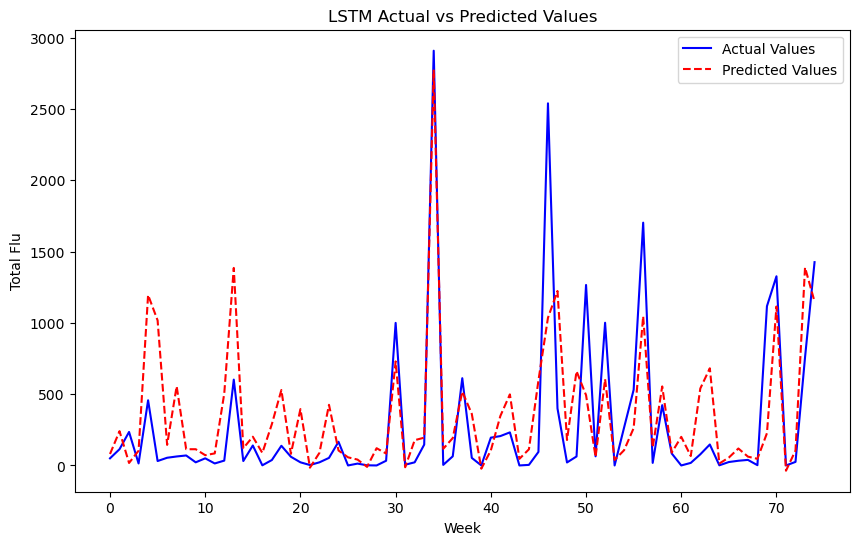

In [33]:
 
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label='Actual Values', color='blue')
plt.plot(y_pred, label='Predicted Values', color='red', linestyle='--')
plt.title('LSTM Actual vs Predicted Values')
plt.xlabel('Week')
plt.ylabel('Total Flu')
plt.legend()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_22016\1890678473.py:6: RuntimeWarning: invalid value encountered in log1p
  y_pred_log = np.log1p(y_pred)


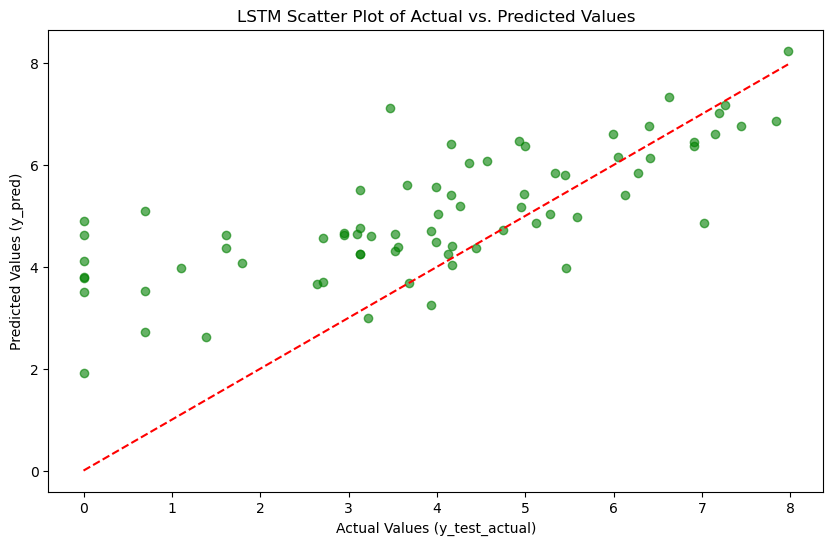

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Apply log transformation to both actual and predicted values
y_test_log = np.log1p(y_test_actual)  # log1p(x) to handle zeros
y_pred_log = np.log1p(y_pred)

# Create scatter plot for log-transformed values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_log, y_pred_log, color='green', alpha=0.6)  # Green dots for scatter
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], color='red', linestyle='--')  # 45-degree line

# Add labels and title
plt.title("LSTM Scatter Plot of Actual vs. Predicted Values")
plt.xlabel("Actual Values (y_test_actual)")
plt.ylabel("Predicted Values (y_pred)")

# Show plot
plt.show()


# LSTM + WV

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
import math

# Define features and target
features = ['Temperature', 'Wind_speed', 'Surface_Pressure', 'relative_humidity']
target = 'total_flu'

# Step 1: Prepare the data
X = fl[features].values  # Feature matrix
y = fl[target].values  # Target variable

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features to [0, 1] range (required for neural networks)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_Y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_Y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_Y.transform(y_test.reshape(-1, 1))

# Reshape input for LSTM (LSTM expects input as [samples, time steps, features])
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the LSTM model with the provided hyperparameters
def create_lstm_model(learning_rate=0.01, units=64):
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=True, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))  # First LSTM layer
    model.add(LSTM(units=units))  # Second LSTM layer
    model.add(Dense(1))  # Output layer for regression

    # Compile the model with the Adam optimizer and learning rate of 0.01
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

# Wrap the LSTM model with KerasRegressor for RandomizedSearchCV
model = KerasRegressor(build_fn=create_lstm_model, verbose=0)

# Define the hyperparameter grid for RandomizedSearchCV
param_dist = {
    'batch_size': [16, 32],    
    'epochs': [50, 100, 200], 
    'learning_rate': [0.001, 0.01],  
    'units': [64, 128]        
}

# Set up RandomizedSearchCV with n_jobs=1 to disable parallelism
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=20, cv=3, random_state=42, n_jobs=1)

# Fit RandomizedSearchCV to the data
random_search.fit(X_train_scaled, y_train_scaled)

# Get the best estimator and print the best parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_
print(f"Best Parameters: {best_params}")

# Make predictions on the test set using the best model
y_pred_scaled = best_model.predict(X_test_scaled)

# Inverse transform the scaled predictions and actual values
y_pred = scaler_Y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_actual = scaler_Y.inverse_transform(y_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

# Create a DataFrame for the metrics
metrics_df = pd.DataFrame({
    'Metric': ['R-squared', 'MSE', 'MAE', 'RMSE'],
    'Value': [r2, mse, mae, rmse]
})

# Display the DataFrame as a table
metrics_df.style.set_caption('LSTM Model Evaluation Metrics')

# Display the metrics DataFrame
metrics_df


In [36]:
# Print the evaluation metrics with formatted output
print(f"R-squared: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


R-squared: 0.187
MSE: 248390.17
MAE: 282.41
RMSE: 498.39


# LSTM + AQV

In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
import math

 #Features and target
features = ['NO', 'PM2.5', 'SO2', 'CO']
target = 'total_flu'

# Step 1: Prepare the data
X = fl[features].values  # Feature matrix
y = fl[target].values  # Target variable

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features to [0, 1] range (required for neural networks)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_Y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_Y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_Y.transform(y_test.reshape(-1, 1))

# Reshape input for LSTM (LSTM expects input as [samples, time steps, features])
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Basic LSTM model creation function
def create_lstm_model(learning_rate=0.01, units=64):
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=True, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))  # First LSTM layer
    model.add(LSTM(units=units))  # Second LSTM layer
    model.add(Dense(1))  # Output layer for regression


    optimizer = RMSprop(learning_rate=learning_rate)
    
    # Compile the model
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

# Wrap the LSTM model with KerasRegressor for RandomizedSearchCV
model = KerasRegressor(build_fn=create_lstm_model, verbose=0)

# Define the hyperparameter grid for RandomizedSearchCV
param_dist = {
    'batch_size': [16, 32],    # Try smaller batch sizes
    'epochs': [50, 100, 200],  # Different epoch options
    'learning_rate': [0.001, 0.01],  # Different learning rates
    'units': [64, 128]        # Different LSTM unit sizes
}


# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, cv=3, random_state=42, n_jobs=1)

# Fit RandomizedSearchCV to the data
random_search.fit(X_train_scaled, y_train_scaled)

# Get the best estimator and print the best parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_
print(f"Best Parameters: {best_params}")

# Make predictions on the test set using the best model
y_pred_scaled = best_model.predict(X_test_scaled)

# Inverse transform the scaled predictions and actual values
y_pred = scaler_Y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_actual = scaler_Y.inverse_transform(y_test_scaled)




Best Parameters: {'units': 128, 'learning_rate': 0.001, 'epochs': 200, 'batch_size': 16}


In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import math

# Define features and target
features = ['NO', 'PM2.5', 'SO2', 'CO']
target = 'total_flu'

# Step 1: Prepare the data
X = fl[features].values  # Feature matrix
y = fl[target].values  # Target variable

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features to [0, 1] range (required for neural networks)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_Y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_Y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_Y.fit_transform(y_test.reshape(-1, 1))

# Reshape input for LSTM (LSTM expects input as [samples, time steps, features])
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the LSTM model using Adam optimizer and best parameters
def create_lstm_best_model():
    model = Sequential()
    model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))  # First LSTM layer with 128 units
    model.add(LSTM(units=128))  # Second LSTM layer with 128 units
    model.add(Dense(1))  # Output layer for regression

    # Compile the model with Adam optimizer and a learning rate of 0.01
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

# Create the LSTM model with the best parameters
lstm_model = create_lstm_best_model()

# Train the LSTM model with batch_size=64 and epochs=100
history = lstm_model.fit(X_train_scaled, y_train_scaled, epochs=200, batch_size=16, verbose=2, validation_data=(X_test_scaled, y_test_scaled))

# Make predictions on the test set
y_pred_scaled = lstm_model.predict(X_test_scaled)

# Inverse transform the scaled predictions and actual values
y_pred = scaler_Y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_actual = scaler_Y.inverse_transform(y_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

# Create a DataFrame for the metrics
metrics_df = pd.DataFrame({
    'Metric': ['R-squared', 'MSE', 'MAE', 'RMSE'],
    'Value': [r2, mse, mae, rmse]
})

# Display the metrics DataFrame
metrics_df


Epoch 1/200
19/19 - 9s - loss: 0.0176 - val_loss: 0.0359
Epoch 2/200
19/19 - 0s - loss: 0.0172 - val_loss: 0.0371
Epoch 3/200
19/19 - 0s - loss: 0.0168 - val_loss: 0.0365
Epoch 4/200
19/19 - 0s - loss: 0.0167 - val_loss: 0.0369
Epoch 5/200
19/19 - 0s - loss: 0.0166 - val_loss: 0.0369
Epoch 6/200
19/19 - 0s - loss: 0.0166 - val_loss: 0.0369
Epoch 7/200
19/19 - 0s - loss: 0.0165 - val_loss: 0.0367
Epoch 8/200
19/19 - 0s - loss: 0.0165 - val_loss: 0.0363
Epoch 9/200
19/19 - 0s - loss: 0.0165 - val_loss: 0.0371
Epoch 10/200
19/19 - 0s - loss: 0.0164 - val_loss: 0.0363
Epoch 11/200
19/19 - 0s - loss: 0.0164 - val_loss: 0.0366
Epoch 12/200
19/19 - 0s - loss: 0.0164 - val_loss: 0.0369
Epoch 13/200
19/19 - 0s - loss: 0.0168 - val_loss: 0.0375
Epoch 14/200
19/19 - 0s - loss: 0.0165 - val_loss: 0.0367
Epoch 15/200
19/19 - 0s - loss: 0.0164 - val_loss: 0.0360
Epoch 16/200
19/19 - 0s - loss: 0.0164 - val_loss: 0.0369
Epoch 17/200
19/19 - 0s - loss: 0.0164 - val_loss: 0.0366
Epoch 18/200
19/19 - 0s

,Metric,Value
0,R-squared,0.030788
1,MSE,296205.147503
2,MAE,297.396541
3,RMSE,544.247322
